# Multi-turn Conversation Activation Analysis
Analysis dimensions: conversational behavior / activation-correctness relationship / activation dynamics / layer contribution comparison

## 0. Dependencies and Imports

In [1]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Dependencies imported successfully')

✅ Dependencies imported successfully


## 1. Data Loading

Three loading modes are supported:
- **A**: Specify a folder and automatically load all `.json` files
- **B**: Specify a file list
- **C**: Paste a JSON list directly (for small-scale debugging)

In [2]:
# ============================================================
# Modify settings here to switch the loading mode
# ============================================================

LOAD_MODE = 'files'   # 'folder' | 'files' | 'inline'

DATA_FOLDER = './logs'          # Used when LOAD_MODE='folder'
DATA_FILES  = ['logs/math/sharded-at0-ut0/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl']   # Used when LOAD_MODE='files'

# When LOAD_MODE='inline', paste your JSON list into RAW_DATA
RAW_DATA = [
    # Paste your JSON objects here
]

# ============================================================
def load_records():
    records = []
    if LOAD_MODE == 'folder':
        paths = glob.glob(os.path.join(DATA_FOLDER, '*.json'))
        for p in paths:
            with open(p, 'r', encoding='utf-8') as f:
                obj = json.load(f)
                # Support either a single dict or a list
                records.extend(obj if isinstance(obj, list) else [obj])
    elif LOAD_MODE == 'files':
        for p in DATA_FILES:
            with open(p, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        records.append(json.loads(line))
    elif LOAD_MODE == 'inline':
        records = RAW_DATA
    else:
        raise ValueError(f'Unknown LOAD_MODE: {LOAD_MODE}')
    return records

records = load_records()
print(f'✅ Loaded {len(records)} conversation records in total')

✅ Loaded 94 conversation records in total


## 2. Data Parsing -> Structured DataFrame

In [3]:
def parse_record(rec):
    """Extract all fields required for analysis from a single record."""
    trace = rec.get('trace', [])
    ar    = rec.get('activation_result', {})

    # ---------- Conversational behavior statistics ----------
    response_types = []
    answer_attempts = []
    num_turns = 0          # Number of user turns
    num_assistant = 0
    for entry in trace:
        role = entry.get('role', '')
        if role == 'user':
            num_turns += 1
        elif role == 'assistant':
            num_assistant += 1
        elif role == 'log':
            content = entry.get('content', {})
            if isinstance(content, dict):
                if content.get('type') == 'system-verification':
                    rt = content.get('response', {}).get('response_type', 'unknown')
                    response_types.append(rt)
                elif content.get('type') == 'answer-evaluation':
                    answer_attempts.append({
                        'exact_answer': content.get('exact_answer'),
                        'is_correct':   content.get('is_correct'),
                        'score':        content.get('score', 0.0),
                    })

    rt_counter = Counter(response_types)

    # ---------- Activation values ----------
    delta_scores      = ar.get('delta_scores', [])        # shape: [num_shards]
    cumulative_scores = ar.get('cumulative_scores', [])   # shape: [num_shards+1]
    delta_per_layer   = ar.get('delta_per_layer', [])     # shape: [num_shards, num_layers]
    cumulative_per_layer = ar.get('cumulative_per_layer', [])  # shape: [num_shards+1, num_layers]

    num_layers = len(delta_per_layer[0]) if delta_per_layer else 0
    num_shards = len(delta_scores)

    # First answer attempt vs. final attempt
    first_attempt = answer_attempts[0]  if answer_attempts else {}
    last_attempt  = answer_attempts[-1] if answer_attempts else {}

    # Canonical correctness rule: score == 0 -> incorrect, otherwise correct.
    raw_score = rec.get('score', 0.0)
    try:
        final_score = float(raw_score)
    except (TypeError, ValueError):
        final_score = 0.0
    is_correct_by_score = (final_score != 0.0)

    return {
        # Metadata
        'conv_id':       rec.get('conv_id'),
        'task':          rec.get('task'),
        'task_id':       rec.get('task_id'),
        'conv_type':     rec.get('conv_type'),
        'assistant_model': rec.get('assistant_model'),

        # Outcomes
        'is_correct_raw': rec.get('is_correct'),
        'is_correct':    is_correct_by_score,
        'final_score':   final_score,
        'first_correct': first_attempt.get('is_correct'),
        'num_answer_attempts': len(answer_attempts),

        # Conversational behavior
        'num_user_turns':     num_turns,
        'num_assistant_turns': num_assistant,
        'num_clarifications': rt_counter.get('clarification', 0),
        'num_discussions':    rt_counter.get('discussion', 0),
        'num_answer_resp':    rt_counter.get('answer_attempt', 0),
        'response_types_seq': response_types,   # Full sequence for order analysis

        # Activation values (global)
        'delta_scores':           delta_scores,
        'cumulative_scores':      cumulative_scores,
        'delta_per_layer':        delta_per_layer,
        'cumulative_per_layer':   cumulative_per_layer,
        'num_shards':             num_shards,
        'num_layers':             num_layers

        # Derived activation features
        ,'mean_delta':      np.mean(delta_scores) if delta_scores else np.nan
        ,'max_delta':       np.max(delta_scores)  if delta_scores else np.nan
        ,'final_cumulative': cumulative_scores[-1] if cumulative_scores else np.nan
        ,'peak_delta_shard': int(np.argmax(delta_scores)) if delta_scores else np.nan
    }

parsed = [parse_record(r) for r in records]
df = pd.DataFrame(parsed)
print(f'✅ Parsing completed: {len(df)} rows, {len(df.columns)} columns')
df[['conv_id','task','is_correct','num_user_turns','num_clarifications',
    'mean_delta','final_cumulative']].head(10)

✅ Parsing completed: 94 rows, 26 columns


,conv_id,task,is_correct,num_user_turns,num_clarifications,mean_delta,final_cumulative
0,69cad3a1218b8fe4c3764494,math,False,6,2,0.158049,0.530107
1,69cad3ba218b8fe4c3764495,math,False,6,4,0.195289,0.447745
2,69cad3ff218b8fe4c3764496,math,True,7,1,0.201921,0.514673
3,69cad41b218b8fe4c3764497,math,True,5,2,0.202830,0.503898
4,69cad435218b8fe4c3764498,math,True,5,0,0.225458,0.528507
5,69cad448218b8fe4c3764499,math,False,5,1,0.199413,0.478011
6,69cad46b218b8fe4c376449a,math,False,4,2,0.190852,0.398781
7,69cad476218b8fe4c376449b,math,True,4,3,0.179572,0.448207
8,69cad487218b8fe4c376449c,math,True,4,2,0.233901,0.429879
9,69cad4c5218b8fe4c376449d,math,False,8,4,0.181702,0.534465


In [4]:
# Quick statistics overview (original, unbalanced)
print('=== Basic Statistics (Original) ===')

s = df['is_correct']
correct_cnt = s.eq(True).sum()
incorrect_cnt = s.eq(False).sum()
missing_cnt = s.isna().sum()
valid_cnt = correct_cnt + incorrect_cnt

print(f'Total conversations           : {len(df)}')
print(f'Correct / Incorrect / Missing : {correct_cnt} / {incorrect_cnt}')
print(f'Accuracy (valid only)         : {correct_cnt / valid_cnt:.2%}' if valid_cnt else 'Accuracy (valid only)         : N/A')
print(f'Avg. user turns               : {df.num_user_turns.mean():.1f}')

=== Basic Statistics (Original) ===
Total conversations           : 94
Correct / Incorrect / Missing : 35 / 59
Accuracy (valid only)         : 37.23%
Avg. user turns               : 5.5


In [5]:
# Optional: filter dataset by user_turns before downstream statistics/balancing
print('=== Optional Filter: num_user_turns ===')

# Filter modes: 'all' (no filter) | 'eq' (exact match) | 'range' (inclusive)
TURN_FILTER_MODE = 'range'
TURN_FILTER_EQ = 5           # Used when mode='eq'
TURN_FILTER_RANGE = (5, 6) # Used when mode='range'

before_n = len(df)

if TURN_FILTER_MODE == 'all':
    df_filtered = df.copy()
elif TURN_FILTER_MODE == 'eq':
    df_filtered = df[df['num_user_turns'] == TURN_FILTER_EQ].copy()
elif TURN_FILTER_MODE == 'range':
    lo, hi = TURN_FILTER_RANGE
    df_filtered = df[df['num_user_turns'].between(lo, hi, inclusive='both')].copy()
else:
    raise ValueError(f'Unknown TURN_FILTER_MODE: {TURN_FILTER_MODE}')

after_n = len(df_filtered)
print(f'Rows before filter: {before_n}')
print(f'Rows after filter : {after_n}')

if after_n == 0:
    print('⚠️ Warning: filter removed all rows. Please adjust TURN_FILTER_* settings.')
else:
    print('Top num_user_turns counts after filtering:')
    print(df_filtered['num_user_turns'].value_counts().sort_index().head(10))

# Use filtered dataset in all following analyses
df = df_filtered

=== Optional Filter: num_user_turns ===
Rows before filter: 94
Rows after filter : 54
Top num_user_turns counts after filtering:
num_user_turns
5    31
6    23
Name: count, dtype: int64


In [11]:
# # Optional: balance correct/incorrect counts
# print('=== Optional Balancing ===')

# s = df['is_correct']
# df_valid = df[s.isin([True, False])].copy()

# correct_df = df_valid[df_valid['is_correct'].eq(True)]
# incorrect_df = df_valid[df_valid['is_correct'].eq(False)]
# target_n = min(len(correct_df), len(incorrect_df))

# if target_n > 0:
#     df_balanced = pd.concat([
#         correct_df.sample(n=target_n, random_state=42),
#         incorrect_df.sample(n=target_n, random_state=42),
#     ], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
# else:
#     df_balanced = df_valid.copy()

# s_bal = df_balanced['is_correct']
# correct_bal = s_bal.eq(True).sum()
# incorrect_bal = s_bal.eq(False).sum()
# missing_bal = s_bal.isna().sum()
# valid_bal = correct_bal + incorrect_bal

# print(f'Original size      : {len(df)}')
# print(f'Balanced size      : {len(df_balanced)}')
# print(f'Balanced C/I/M     : {correct_bal} / {incorrect_bal} / {missing_bal}')
# print(f'Balanced accuracy  : {correct_bal / valid_bal:.2%}' if valid_bal else 'Balanced accuracy  : N/A')

# # If you want to use balanced data in later analysis, uncomment next line
# df = df_balanced

---
## 3. Conversational Behavior Analysis
### 3.1 Response Type Distribution

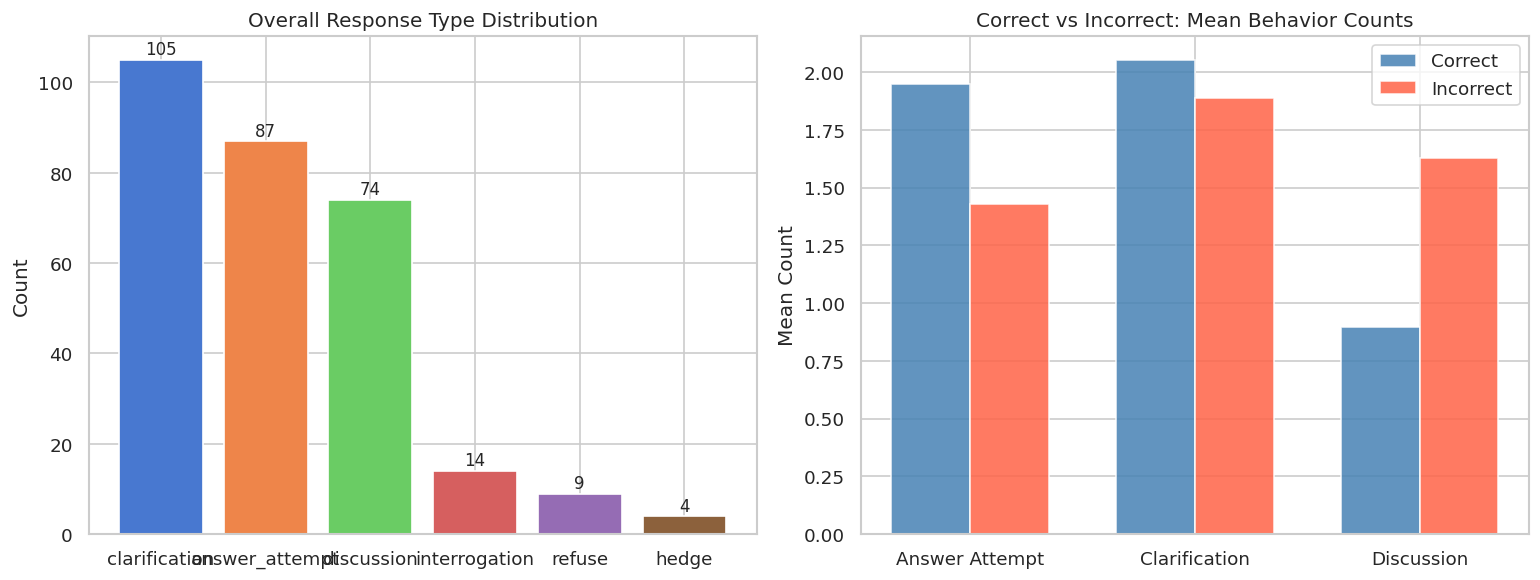

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: overall response type distribution ----
all_types = [t for seq in df.response_types_seq for t in seq]
type_counts = Counter(all_types)
labels, values = zip(*sorted(type_counts.items(), key=lambda x: -x[1]))

bars = axes[0].bar(labels, values, color=sns.color_palette('muted', len(labels)))
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Overall Response Type Distribution')
axes[0].set_ylabel('Count')

# ---- Right: behavior comparison between correct and incorrect conversations ----
behavior_cols = ['num_answer_resp', 'num_clarifications', 'num_discussions']
behavior_labels = ['Answer Attempt', 'Clarification', 'Discussion']
correct_means   = df[df.is_correct == True][behavior_cols].mean()
incorrect_means = df[df.is_correct == False][behavior_cols].mean()

x = np.arange(len(behavior_labels))
w = 0.35
axes[1].bar(x - w/2, correct_means,   w, label='Correct', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, incorrect_means, w, label='Incorrect', color='tomato',    alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(behavior_labels)
axes[1].set_title('Correct vs Incorrect: Mean Behavior Counts')
axes[1].set_ylabel('Mean Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('analyse/fig1_behavior_distribution.png', bbox_inches='tight')
plt.show()

### 3.2 Response Sequence Patterns (Preparation Before First Answer Attempt)

In [7]:
def get_pre_answer_seq(seq):
    """Extract the response sequence before the first answer_attempt."""
    pre = []
    for t in seq:
        if t == 'answer_attempt':
            break
        pre.append(t)
    return tuple(pre)

df['pre_answer_seq'] = df['response_types_seq'].apply(get_pre_answer_seq)
seq_counts = Counter(df['pre_answer_seq'])

seq_df = pd.DataFrame([
    {'sequence': ' -> '.join(k) if k else '(answer directly)', 'count': v}
    for k, v in seq_counts.most_common(10)
])
print('Top-10 most common pre-answer behavior sequences:')
seq_df

Top-10 most common pre-answer behavior sequences:


,sequence,count
0,clarification -> clarification -> clarificatio...,5
1,clarification -> clarification -> clarificatio...,4
2,clarification -> clarification -> discussion -...,3
3,clarification -> clarification,3
4,clarification -> discussion -> discussion,3
5,clarification -> clarification -> clarification,2
6,refuse -> interrogation,2
7,clarification -> clarification -> clarificatio...,2
8,clarification,2
9,discussion -> discussion -> discussion -> disc...,2


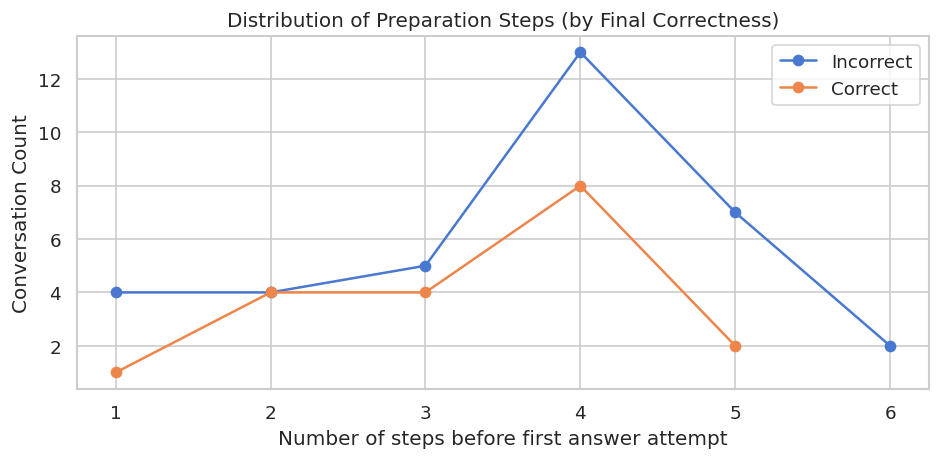

In [8]:
# Number of pre-answer behaviors vs final correctness
df['pre_answer_len'] = df['pre_answer_seq'].apply(len)

fig, ax = plt.subplots(figsize=(8, 4))
for correct, grp in df.groupby('is_correct'):
    label = 'Correct' if correct else 'Incorrect'
    counts = grp['pre_answer_len'].value_counts().sort_index()
    ax.plot(counts.index, counts.values, marker='o', label=label)
ax.set_xlabel('Number of steps before first answer attempt')
ax.set_ylabel('Conversation Count')
ax.set_title('Distribution of Preparation Steps (by Final Correctness)')
ax.legend()
plt.tight_layout()
plt.savefig('analyse/fig2_pre_answer_steps.png', bbox_inches='tight')
plt.show()

---
## 4. Relationship Between Activation Values and Answer Correctness
### 4.1 Correct vs Incorrect: Activation Distribution Comparison

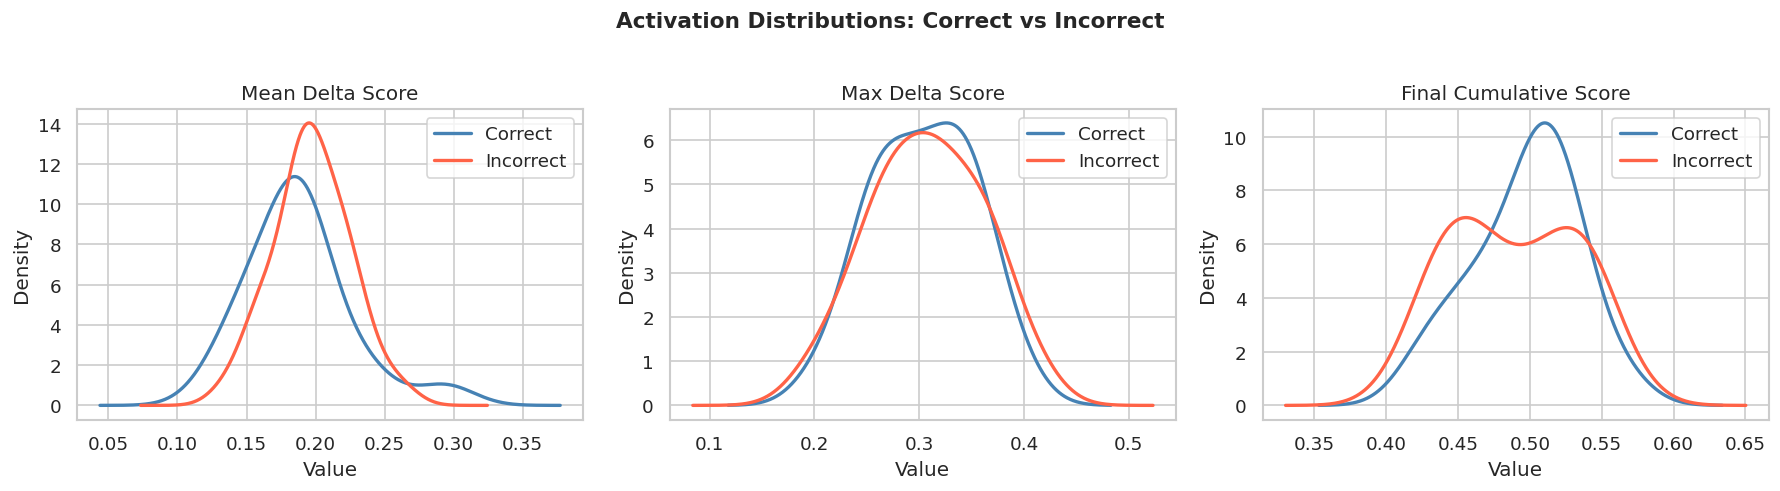

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('mean_delta',       'Mean Delta Score'),
    ('max_delta',        'Max Delta Score'),
    ('final_cumulative', 'Final Cumulative Score'),
]

for ax, (col, title) in zip(axes, metrics):
    for correct, color, label in [(True, 'steelblue', 'Correct'), (False, 'tomato', 'Incorrect')]:
        vals = df[df.is_correct == correct][col].dropna()
        if len(vals) > 1:
            vals.plot.kde(ax=ax, label=label, color=color, linewidth=2)
        else:
            ax.axvline(vals.iloc[0] if len(vals) else 0, color=color,
                       linestyle='--', label=f'{label} (n={len(vals)})')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.legend()

plt.suptitle('Activation Distributions: Correct vs Incorrect', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analyse/fig3_activation_vs_correctness.png', bbox_inches='tight')
plt.show()

In [10]:
# Statistical test: mean comparison
from scipy import stats

print('=== Activation Features: Correct vs Incorrect Mean Comparison ===')
print(f'{'Feature':<25} {'Correct Mean':>12} {'Incorrect Mean':>14} {'p-value':>10}')
print('-' * 64)

for col, title in metrics:
    correct_vals   = df[df.is_correct == True][col].dropna()
    incorrect_vals = df[df.is_correct == False][col].dropna()
    if len(correct_vals) >= 2 and len(incorrect_vals) >= 2:
        _, p = stats.mannwhitneyu(correct_vals, incorrect_vals, alternative='two-sided')
        print(f'{title:<25} {correct_vals.mean():>12.4f} {incorrect_vals.mean():>14.4f} {p:>10.4f}')
    else:
        print(f'{title:<25} {correct_vals.mean():>12.4f} {"N/A":>14} {"N/A":>10}')

=== Activation Features: Correct vs Incorrect Mean Comparison ===
Feature                   Correct Mean Incorrect Mean    p-value
----------------------------------------------------------------
Mean Delta Score                0.1878         0.1971     0.1375
Max Delta Score                 0.3042         0.3073     0.7720
Final Cumulative Score          0.4970         0.4889     0.6120


### 4.2 Scatter Plot: Activation Value vs Final Score

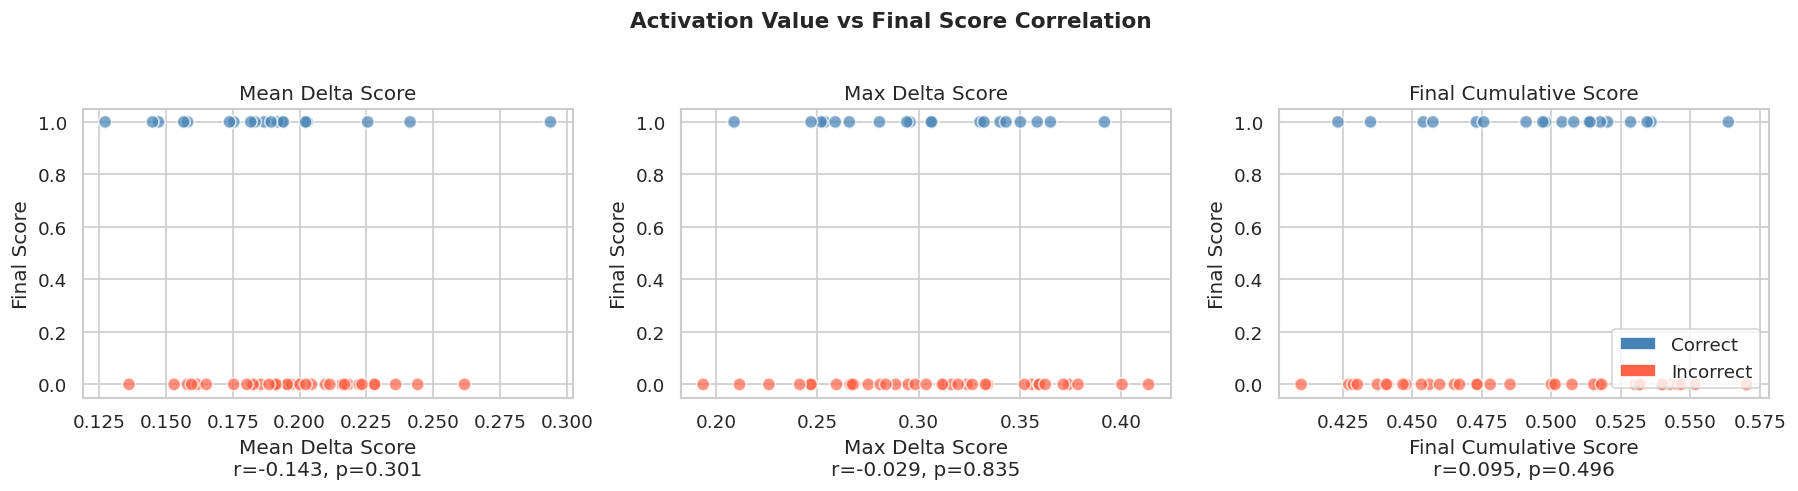

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, title) in zip(axes, metrics):
    sub = df[[col, 'final_score', 'is_correct']].dropna()
    colors = sub['is_correct'].map({True: 'steelblue', False: 'tomato'})
    ax.scatter(sub[col], sub['final_score'], c=colors, alpha=0.7, edgecolors='white', s=60)
    # Correlation coefficient
    if len(sub) >= 3:
        r, p = stats.pearsonr(sub[col], sub['final_score'])
        ax.set_xlabel(f'{title}\nr={r:.3f}, p={p:.3f}')
    else:
        ax.set_xlabel(title)
    ax.set_ylabel('Final Score')
    ax.set_title(title)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Correct'),
                   Patch(facecolor='tomato',    label='Incorrect')]
axes[-1].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Activation Value vs Final Score Correlation', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analyse/fig4_activation_score_scatter.png', bbox_inches='tight')
plt.show()

---
## 5. Dynamic Activation Trends in Multi-turn Conversations
### 5.1 Mean Activation Curves (by Shard Step)

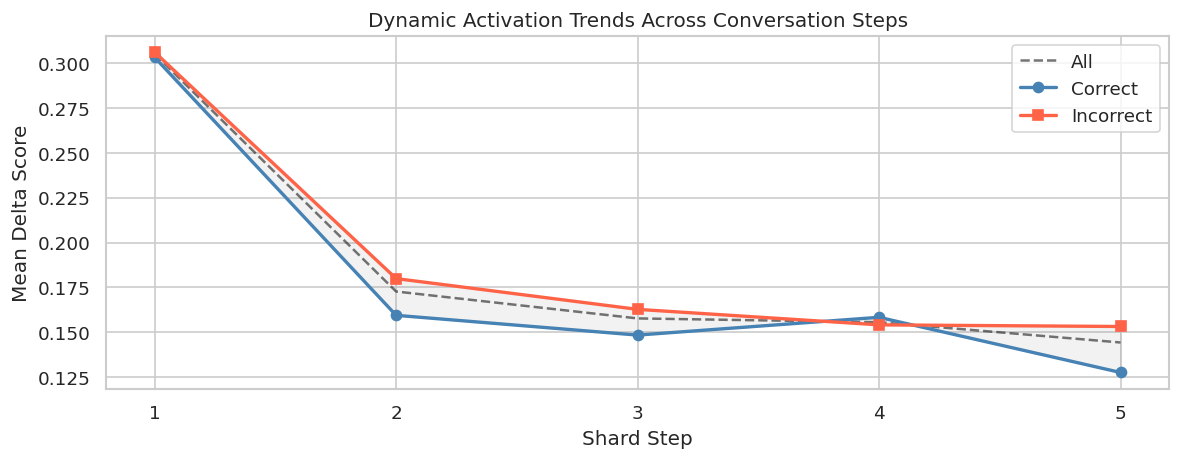

In [12]:
def pad_or_trim(arr, length, pad_val=np.nan):
    arr = list(arr)
    if len(arr) >= length:
        return arr[:length]
    return arr + [pad_val] * (length - len(arr))

# Find the maximum shard length
max_shards = df['num_shards'].max()

# Align delta_scores
delta_matrix = np.array([
    pad_or_trim(row, max_shards) for row in df['delta_scores']
])  # shape: [N, max_shards]

mean_delta_correct   = np.nanmean(delta_matrix[df.is_correct == True],  axis=0)
mean_delta_incorrect = np.nanmean(delta_matrix[df.is_correct == False], axis=0)
mean_delta_all       = np.nanmean(delta_matrix, axis=0)

steps = np.arange(1, max_shards + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, mean_delta_all,       'k--',  label='All',       linewidth=1.5, alpha=0.6)
ax.plot(steps, mean_delta_correct,   'o-',   label='Correct',   color='steelblue', linewidth=2)
ax.plot(steps, mean_delta_incorrect, 's-',   label='Incorrect', color='tomato',    linewidth=2)
ax.fill_between(steps, mean_delta_correct, mean_delta_incorrect, alpha=0.1, color='gray')
ax.set_xlabel('Shard Step')
ax.set_ylabel('Mean Delta Score')
ax.set_title('Dynamic Activation Trends Across Conversation Steps')
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('analyse/fig5_activation_trend.png', bbox_inches='tight')
plt.show()

### 5.2 Cumulative Score Trajectories: One Curve per Conversation

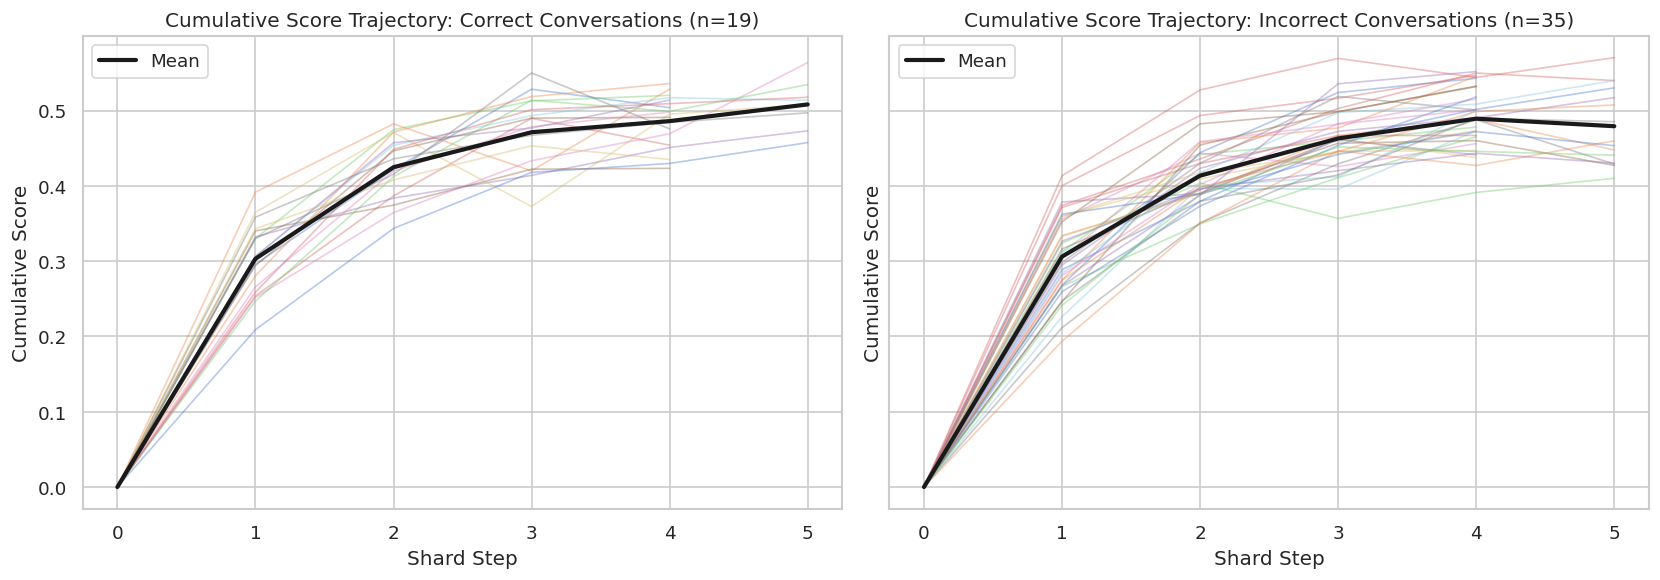

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titles    = ['Correct Conversations', 'Incorrect Conversations']
subsets   = [df[df.is_correct == True], df[df.is_correct == False]]

for ax, title, sub in zip(axes, titles, subsets):
    for _, row in sub.iterrows():
        cum = row['cumulative_scores']
        if cum:
            ax.plot(range(len(cum)), cum, alpha=0.4, linewidth=1)
    # Draw mean trajectory
    cum_matrix = np.array([pad_or_trim(r, max_shards + 1)
                            for r in sub['cumulative_scores']])
    mean_line = np.nanmean(cum_matrix, axis=0)
    ax.plot(range(len(mean_line)), mean_line, 'k-', linewidth=2.5, label='Mean')
    ax.set_title(f'Cumulative Score Trajectory: {title} (n={len(sub)})')
    ax.set_xlabel('Shard Step')
    ax.set_ylabel('Cumulative Score')
    ax.legend()

plt.tight_layout()
plt.savefig('analyse/fig6_cumulative_trajectories.png', bbox_inches='tight')
plt.show()

### 5.3 Peak Delta Position Analysis (When Does the Model "Click"?)

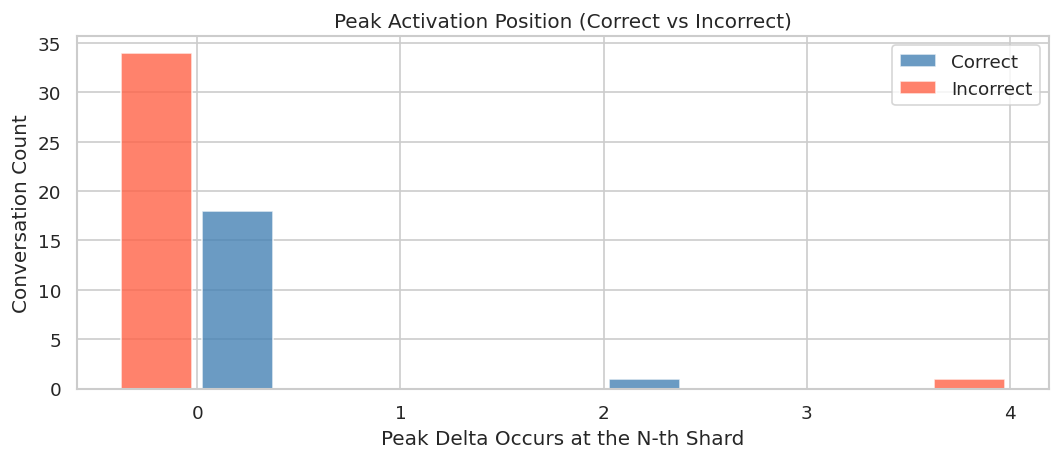

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))

for correct, color, label in [(True, 'steelblue', 'Correct'), (False, 'tomato', 'Incorrect')]:
    sub = df[df.is_correct == correct]['peak_delta_shard'].dropna().astype(int)
    counts = sub.value_counts().sort_index()
    ax.bar(counts.index + (0.2 if correct else -0.2),
           counts.values, 0.35,
           color=color, alpha=0.8, label=label)

ax.set_xlabel('Peak Delta Occurs at the N-th Shard')
ax.set_ylabel('Conversation Count')
ax.set_title('Peak Activation Position (Correct vs Incorrect)')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.savefig('analyse/fig7_peak_delta_position.png', bbox_inches='tight')
plt.show()

---
## 6. Activation Contribution Comparison Across Layers
### 6.1 Mean Layer Delta (Global)

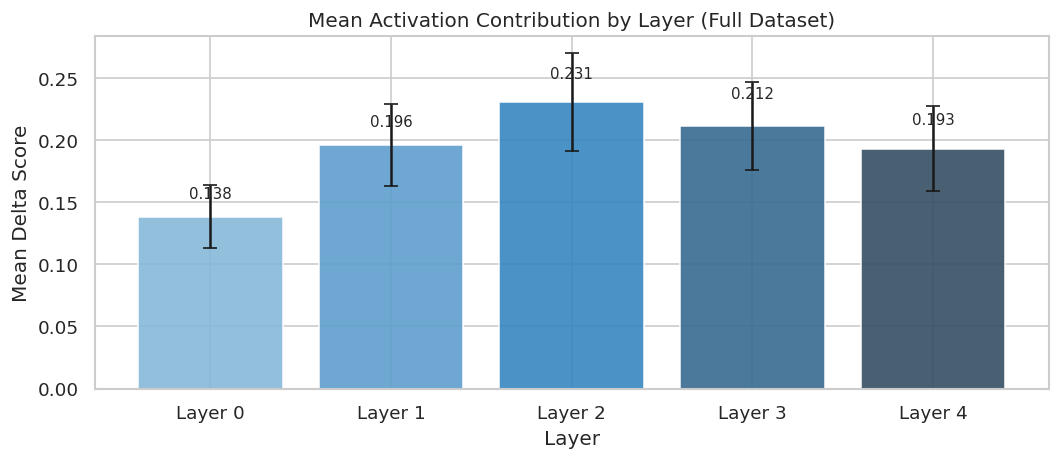

In [15]:
# Aggregate delta_per_layer from each record -> shape: [num_shards, num_layers]
# Use all records and compute per-layer means

all_layer_deltas = []  # Each element is a [num_layers] vector (mean over all shards)
for _, row in df.iterrows():
    dpl = row['delta_per_layer']
    if dpl:
        arr = np.array(dpl)   # [num_shards, num_layers]
        all_layer_deltas.append(arr.mean(axis=0))  # mean over shards -> [num_layers]

if all_layer_deltas:
    layer_mean = np.nanmean(all_layer_deltas, axis=0)  # [num_layers]
    layer_std  = np.nanstd(all_layer_deltas,  axis=0)
    num_layers_plot = len(layer_mean)

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(num_layers_plot)
    bars = ax.bar(x, layer_mean, yerr=layer_std, capsize=4,
                  color=sns.color_palette('Blues_d', num_layers_plot), alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Layer {i}' for i in x])
    ax.set_xlabel('Layer')
    ax.set_ylabel('Mean Delta Score')
    ax.set_title('Mean Activation Contribution by Layer (Full Dataset)')
    for bar, val in zip(bars, layer_mean):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + layer_std[bar.get_x().__int__()] * 0.5,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('analyse/fig8_layer_contribution.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠️ No delta_per_layer data available')

### 6.2 Layer Contribution Heatmap: Correct vs Incorrect x Shard Step

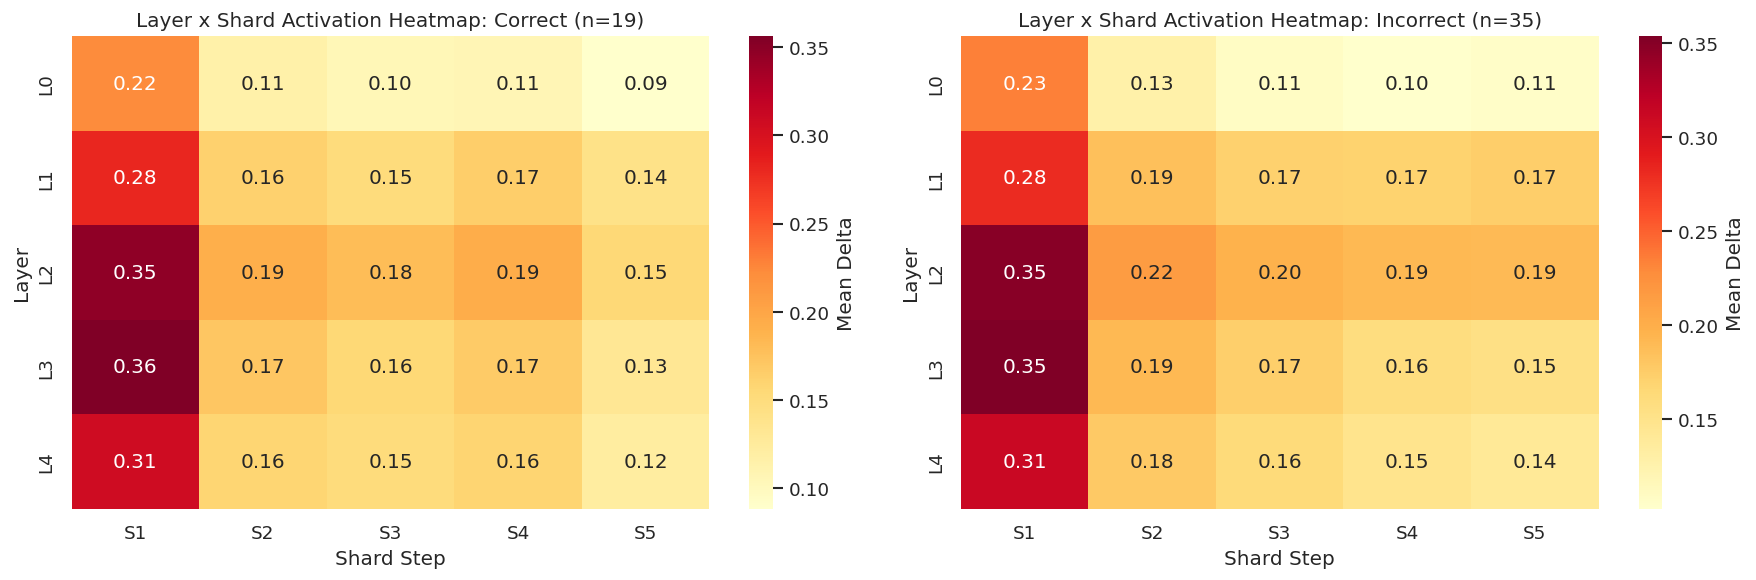

In [16]:
def build_layer_heatmap(subset_df, max_shards, num_layers):
    """Build a mean activation heatmap with shape [max_shards, num_layers]."""
    accum = np.zeros((max_shards, num_layers))
    count = np.zeros((max_shards, num_layers))
    for _, row in subset_df.iterrows():
        dpl = row['delta_per_layer']
        if dpl:
            arr = np.array(dpl)  # [shards, layers]
            s, l = arr.shape
            accum[:s, :l] += arr
            count[:s, :l] += 1
    with np.errstate(invalid='ignore'):
        return np.where(count > 0, accum / count, np.nan)

if all_layer_deltas:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, correct, title in [
        (axes[0], True,  'Correct'),
        (axes[1], False, 'Incorrect'),
    ]:
        sub = df[df.is_correct == correct]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue
        heatmap = build_layer_heatmap(sub, max_shards, num_layers_plot)
        sns.heatmap(
            heatmap.T,   # transpose: rows=layer, cols=shard
            ax=ax,
            cmap='YlOrRd',
            annot=True, fmt='.2f',
            xticklabels=[f'S{i+1}' for i in range(max_shards)],
            yticklabels=[f'L{i}'   for i in range(num_layers_plot)],
            cbar_kws={'label': 'Mean Delta'},
        )
        ax.set_title(f'Layer x Shard Activation Heatmap: {title} (n={len(sub)})')
        ax.set_xlabel('Shard Step')
        ax.set_ylabel('Layer')

    plt.tight_layout()
    plt.savefig('analyse/fig9_layer_shard_heatmap.png', bbox_inches='tight')
    plt.show()

### 6.3 Layer Contribution Difference: Correct - Incorrect (Difference Heatmap)

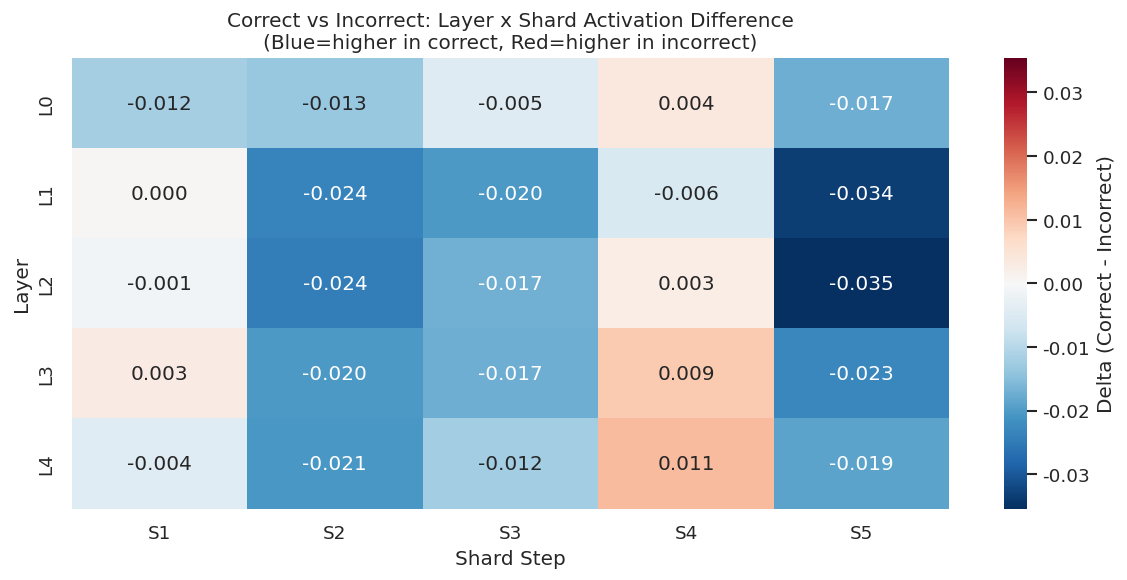

In [17]:
if all_layer_deltas:
    hm_correct   = build_layer_heatmap(df[df.is_correct == True],  max_shards, num_layers_plot)
    hm_incorrect = build_layer_heatmap(df[df.is_correct == False], max_shards, num_layers_plot)
    diff = hm_correct - hm_incorrect

    fig, ax = plt.subplots(figsize=(10, 5))
    vmax = np.nanmax(np.abs(diff))
    sns.heatmap(
        diff.T,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        vmin=-vmax, vmax=vmax,
        annot=True, fmt='.3f',
        xticklabels=[f'S{i+1}' for i in range(max_shards)],
        yticklabels=[f'L{i}'   for i in range(num_layers_plot)],
        cbar_kws={'label': 'Delta (Correct - Incorrect)'},
    )
    ax.set_title('Correct vs Incorrect: Layer x Shard Activation Difference\n(Blue=higher in correct, Red=higher in incorrect)')
    ax.set_xlabel('Shard Step')
    ax.set_ylabel('Layer')
    plt.tight_layout()
    plt.savefig('analyse/fig10_layer_diff_heatmap.png', bbox_inches='tight')
    plt.show()

---
## 7. Summary Table

In [25]:
summary = df.groupby('is_correct').agg(
    Sample_Count         = ('conv_id',           'count'),
    Mean_User_Turns      = ('num_user_turns',     'mean'),
    Mean_Clarification   = ('num_clarifications', 'mean'),
    Mean_Discussion      = ('num_discussions',    'mean'),
    Mean_Answer_Attempt  = ('num_answer_resp',    'mean'),
    Mean_Mean_Delta      = ('mean_delta',         'mean'),
    Mean_Max_Delta       = ('max_delta',          'mean'),
    Mean_Final_Cum       = ('final_cumulative',   'mean'),
).round(3)
summary.index = summary.index.map({True: 'Correct', False: 'Incorrect'})
print('=== Summary Statistics Table ===')
summary

=== Summary Statistics Table ===


,Sample_Count,Mean_User_Turns,Mean_Clarification,Mean_Discussion,Mean_Answer_Attempt,Mean_Mean_Delta,Mean_Max_Delta,Mean_Final_Cum
is_correct,,,,,,,,
Incorrect,34,5.324,1.471,1.735,1.441,0.197,0.312,0.489
Correct,21,5.619,1.810,1.238,1.952,0.184,0.305,0.494


In [26]:
# Export to CSV
df_export = df.drop(columns=['delta_scores','cumulative_scores',
                              'delta_per_layer','cumulative_per_layer',
                              'response_types_seq','pre_answer_seq'])
df_export.to_csv('analyse/analysis_results.csv', index=False)
print('✅ Exported analysis_results.csv')

✅ Exported analysis_results.csv


In [1]:
from utils_log import aggregate_hidden_states_from_folder

# 聚合一个配置下所有 conversations 的 hidden states
aggregate_hidden_states_from_folder(
    "/home/jie/projects/lost_in_conversation/logs/hidden_states/math/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)

✅ Aggregated 102 hidden states files -> logs/hidden_states_aggregated/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct_aggregated.npz
   Turns found: ['goal', 'turn_1', 'turn_10', 'turn_11', 'turn_2', 'turn_3', 'turn_4', 'turn_5', 'turn_6', 'turn_7', 'turn_8', 'turn_9']


'logs/hidden_states_aggregated/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct_aggregated.npz'